# **Anomaly Detection Model Training Notebook**



---
## Setup Environment

In [ ]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 79.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT3/data


---
## Student Information

In [ ]:
group_name = "Group 11"
student_name = "Rose Marie Tazbaz"
student_id = "25742507"

In [ ]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [ ]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [ ]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [ ]:
# <Student to fill this section>

### 0.b Import Packages

In [ ]:
# <Student to fill this section>
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## B. Business Understanding

In [ ]:
business_use_case_description = "The objective of this research project is to create a machine learning model that will identify any abnormalities in sales transactions and abnormal behavior in sales transactions in the retail company's sales data. In this research project, the primary task is to detect any potential fraudulent transactions, inconsistencies in prices, irregularities in operations, and any abnormal purchase behavior that may adversely affect the company's operations. By analyzing the transactional, product, price, and operational data, the proposed machine learning algorithms intend to enable the early detection of any anomalies that may signal fraud, inconsistencies, problems with inventory, pricing, or any other irregular customer behavior. This particular research project is significant for any large retail setting because manually tracking thousands of transactions can be quite cumbersome."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [ ]:
business_objectives = "Successful anomaly detection may prove beneficial to the company in identifying suspicious deals, discrepancies with prices, irregularities in operations, and unusual buying patterns. Such anomalies may contribute to reduced financial risks, efficient operations, enhanced prevention of fraud, as well as effective inventory and price control. At the same time, the wrong results obtained from the process may have a detrimental effect on the business performance. Incorrect predictions may include false positives when legitimate deals are considered to be anomalous ones. This may lead to unnecessary actions such as excessive investigations or inefficient use of resources. On the other hand, false negatives will result in undetected fraudulent and irregular behavior by the company's employees, thus increasing the risks involved."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [ ]:
stakeholders_expectations_explanations = "Anomaly detection predictions can be expected to assist with the process of operational monitoring and business decision-making procedures for the retail company. Anomalies can be assessed by business analysts, fraud detection departments, operational managers, pricing departments, and inventory control departments to detect any suspicious or abnormal transaction activity. Predictions can be applied to prioritize the review of transactions, investigate any abnormal price activity, monitor any abnormal purchasing behavior, and find any operational inconsistencies that require additional assessment. Some of the key stakeholders affected by predictions are internal retail operation departments, management departments, fraud prevention analysts, and even customers if there is any transaction activity that may cause any problems while purchasing goods."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Datasets


In [ ]:
# datasets from notebook a

try:
    X_train = pd.read_csv(at.folder_path / "X_train.csv")
    X_val = pd.read_csv(at.folder_path / "X_val.csv")
    X_test = pd.read_csv(at.folder_path / "X_test.csv")

    print("Training shape:", X_train.shape)
    print("Validation shape:", X_val.shape)
    print("Testing shape:", X_test.shape)

except Exception as e:
    print(e)

Training shape: (54113, 75)
Validation shape: (11596, 75)
Testing shape: (11596, 75)


### C.2 Define Target variable

In [ ]:
# This project applies unsupervised anomaly detection. Therefore, no explicit target variable is available in the dataset.

target_variable = None

print("Target variable:", target_variable)

Target variable: None


In [ ]:
target_definition_explanations = "The current project is an example of unsupervised anomaly detection, implying that there is no target variable representing the labels of the anomaly class present in the dataset. Contrary to supervised machine learning problems like classification or regression where target variables represent class labels explicitly, anomaly detection relies on discovering outliers on the basis of deviations from the normal behavioral pattern. From the business point of view, the project aims at detecting unusual sales orders, abnormal pricing patterns, discrepancies in operations, as well as suspicious transactions in the retail sales data. Due to the absence of any historical labels for transactions classified as fraudulent or anomalies, machine learning models should be able to discover these classes based on the features of transactional and operational activity represented in the data. Thus, there were no target variables used in the learning phase of anomaly prediction models. On the contrary, models like Isolation Forest and Local Outlier Factor will learn to predict anomalies by analyzing observations which deviate significantly from others."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [ ]:
target_name = None
print("Target variable:", target_name)

Target variable: None


In [ ]:
create_target_variable_explanations = "There's no explicit target variable in this project because the anomaly detection task is unsupervised, hence, the model will identify anomalous transactions based on deviations from normal transactional behavior rather than predefined labels."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='create_target_variable_explanations', value=create_target_variable_explanations)

### C.4 Explore Target variable

In [ ]:
anomaly_related_features = ['price_difference_ratio', 'discounted_amount']
X_train[anomaly_related_features].describe()

,price_difference_ratio,discounted_amount
count,54113.000000,54113.000000
mean,3.058963,2.522873
std,15.188168,42.953901
min,-0.939292,0.000000
25%,-0.194646,0.000000
50%,0.000000,0.000000
75%,0.805354,0.000000
max,109.527118,4005.237600


In [ ]:
target_distribution_explanations = "As the current study utilizes unsupervised anomaly detection techniques, there is no specific target variable label present within the dataset. Rather, the analysis of variables with the potential to be highly correlated with anomalies was conducted in order to determine the nature of the anomalies that could be detected by the model. The price_difference_ratio and discounted_amount variables show very high variance and extreme values, hence their relevance for building an anomaly detection model. In addition, the price_difference_ratio variable has both negative and very high positive values. In much the same way, there is an extremely skewed distribution in relation to the discounted_amount characteristic where there is generally no discount amount involved in the majority of the sales transactions, whereas only a few observations have an abnormally high discount amount. This could indicate promotional discounts, mass buying, inconsistencies in operations, or even possibly fraudulent behavior. It is likely that these characteristics can be used to distinguish between abnormal transactions due to their skewed distributions."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `price_difference_ratio`

In [ ]:
X_train['price_difference_ratio'].describe()

,price_difference_ratio
count,54113.000000
mean,3.058963
std,15.188168
min,-0.939292
25%,-0.194646
50%,0.000000
75%,0.805354
max,109.527118


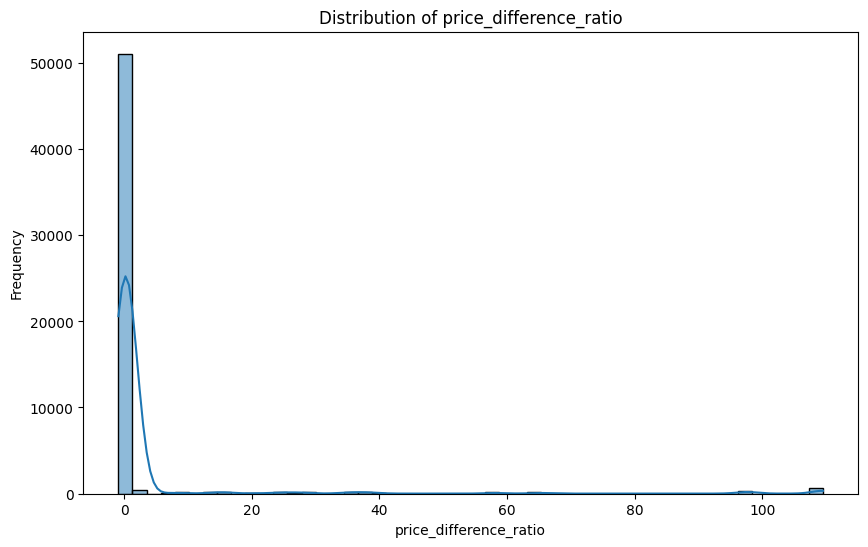

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(X_train['price_difference_ratio'], bins=50, kde=True)
plt.title('Distribution of price_difference_ratio')
plt.xlabel('price_difference_ratio')
plt.ylabel('Frequency')
plt.show()

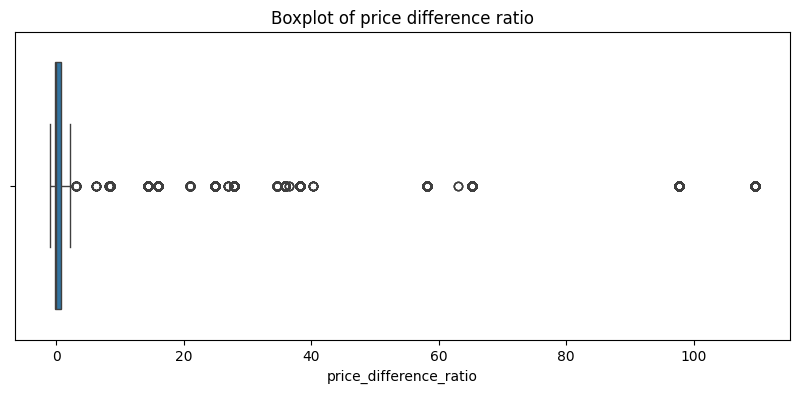

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(x=X_train['price_difference_ratio'])
plt.title("Boxplot of price difference ratio")
plt.show()

In [ ]:
X_train['price_difference_ratio'].sort_values(ascending=False).head(10)

,price_difference_ratio
11215,109.527118
1370,109.527118
48939,109.527118
48784,109.527118
48782,109.527118
48755,109.527118
48732,109.527118
12216,109.527118
12196,109.527118
10986,109.527118


In [ ]:
feature_1_insights = "The distribution of the price_difference_ratio attribute is strongly positively skewed, with most data points being around zero, while a few data points have very high positive values. There is a large discrepancy between the median, which is zero, and the maximum, which is 109.53, implying the existence of several outliers with unusually high markup rates. Box plots provide evidence of many extreme outliers, indicating that some transactions have occurred whereby goods have been sold at prices way above the regular prices. These could be premium products or just some cases of abnormal selling behavior or pricing. Some negative values have also been observed in the dataset. In terms of anomaly detection, the feature is highly applicable since it identifies the occurrence of financial anomalies such as pricing inconsistencies in the transaction data set. The presence of high positive skewness and high standard deviation means that this feature could help identify some forms of abnormal transactional activities in the retail data set. A shortcoming associated with the use of the feature is the fact that normal premium transactions will produce extreme values too. This means that extra transaction variables and business data need to be considered in the analysis."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `discounted_amount`

In [ ]:
X_train['discounted_amount'].describe()

,discounted_amount
count,54113.000000
mean,2.522873
std,42.953901
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,4005.237600


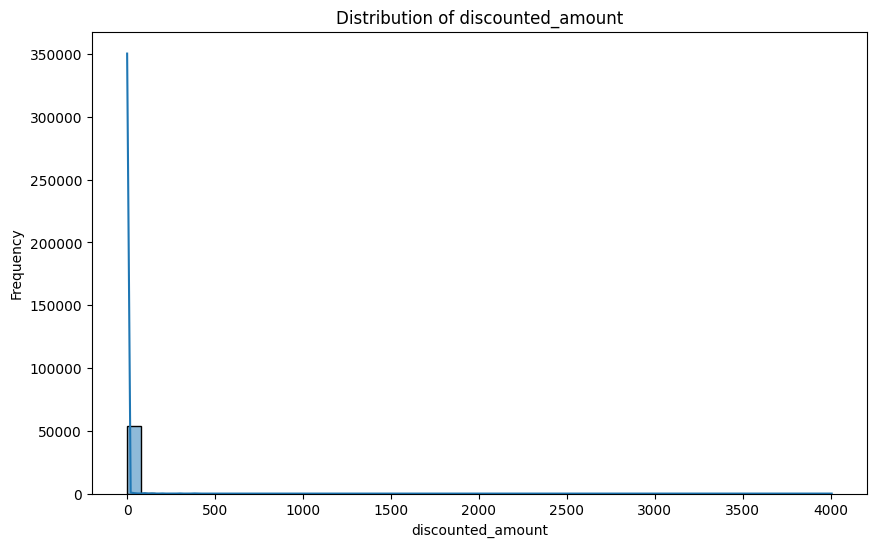

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(X_train['discounted_amount'], bins=50, kde=True)
plt.title('Distribution of discounted_amount')
plt.xlabel('discounted_amount')
plt.ylabel('Frequency')
plt.show()

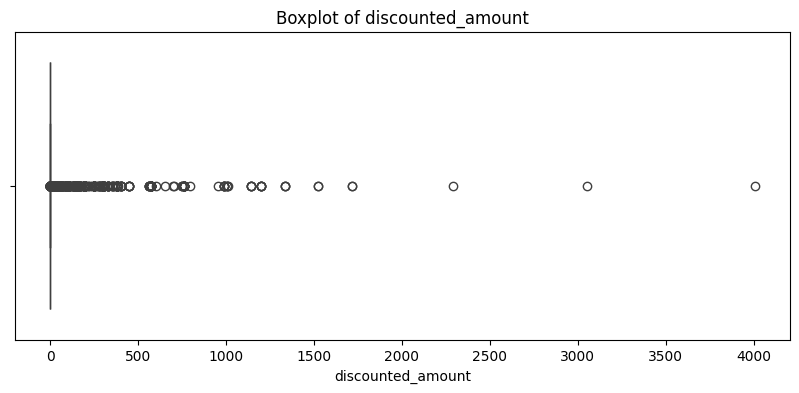

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(x=X_train['discounted_amount'])
plt.title("Boxplot of discounted_amount")
plt.show()

In [ ]:
X_train['discounted_amount'].sort_values(ascending=False).head(10)

,discounted_amount
21185,4005.2376
51180,3051.6096
29908,2288.7072
45682,1716.5304
15102,1716.5304
15554,1525.8048
32787,1525.8048
3868,1335.0792
18766,1335.0792
27113,1335.0792


In [ ]:
feature_2_insights = "The feature 'discounted_amount' displays a very skewed right distribution with most of the transactions displaying an absence of any discount and a few transactions carrying large discount values. This has been highlighted through the values of median and the upper quartile being zero, but the maximum value of the discounted amount being more than 4000. Through the histogram and the box plot, it can be seen that there are some extreme outliers within the data. This means that only a few transactions carry high discounts. These high discount values could be related to promotions, bulk purchases, price irregularities, and possible fraud. In business, it is clear that high discount values can make a huge difference in terms of sales and profit. With respect to anomaly detection, this feature proves to be very useful because the behaviors with regards to discounting in terms of being unusual and extreme are significantly different from the regular transactions within a retail environment. The high degree of skewness together with the high concentration of zeroes can be interpreted as indicating that discount-based anomalies can be easily identified by anomaly detection systems. The downside of using such a feature as a way of identifying anomalies is that some promotional sales campaigns may also lead to extreme discounts."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `sub_total`


In [ ]:
X_train['sub_total'].describe()

,sub_total
count,54113.000000
mean,2.816745
std,6.705936
min,-0.577483
25%,-0.546885
50%,0.000000
75%,0.453115
max,41.899956


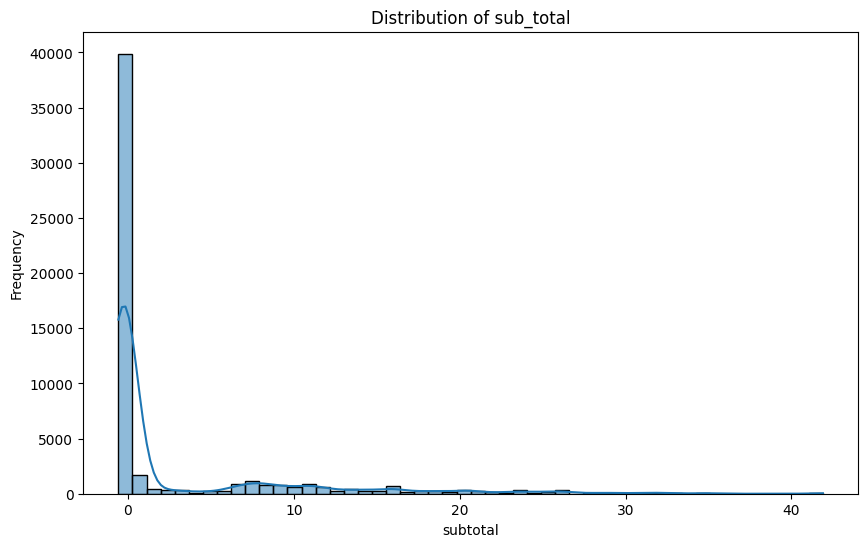

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(X_train['sub_total'], bins=50, kde=True)
plt.title('Distribution of sub_total')
plt.xlabel('subtotal')
plt.ylabel('Frequency')
plt.show()

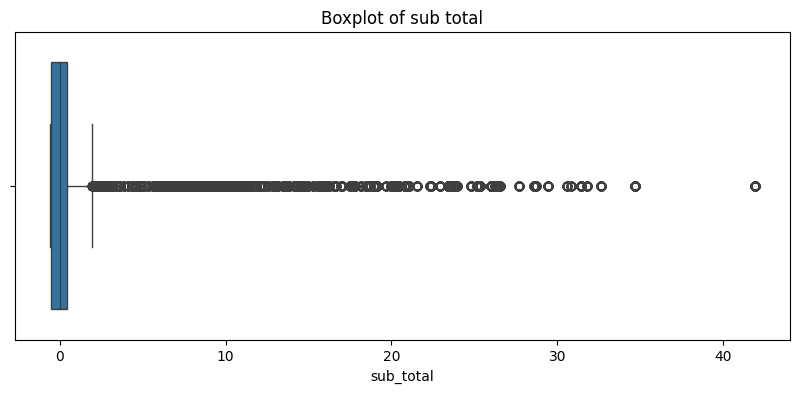

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(x=X_train['sub_total'])
plt.title("Boxplot of sub total")
plt.show()

In [ ]:
X_train['sub_total'].sort_values(ascending=False).head(10)

,sub_total
54035,41.899956
36814,41.899956
3450,41.899956
22948,41.899956
17470,41.899956
33436,41.899956
48375,41.899956
44503,41.899956
51680,41.899956
6605,41.899956


In [ ]:
feature_3_insights = "Subtotal shows a very strong right-skewed distribution, where the largest number of transactions take place at relatively small values, while a lower number of transactions has considerably larger amounts of money spent. This is supported by the considerable gap between the median value, which is 0.00, and the maximum value, which is 41.90, showing that there are outliers in the dataset. The histogram and box plot support this fact because even though most sales orders are close to each other, there are several very different observations from the rest. Additionally, negative values were noted in the distribution of features owing to the presence of scaling transformations performed on the dataset during the preprocessing stage. Notwithstanding the aforementioned scaling transformation, the feature maintains significant variability and also outlier characteristics that can assist in the anomaly detection process. Considering the effect of extreme transaction total values in terms of a business, one might conclude that high sub_total figures can have substantial meaning when it comes to detecting anomalies related to customers' purchasing behavior or sales performance. The downside associated with using the feature is that real transactions can actually represent outliers. Hence, more features will need to be included to differentiate between anomalies and legitimate business transactions."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.8 Explore Feature of Interest `weight`

In [ ]:
X_train['weight'].describe()

,weight
count,54113.000000
mean,5.790324
std,53.398491
min,-18.010000
25%,0.000000
50%,0.000000
75%,0.000000
max,1029.870000


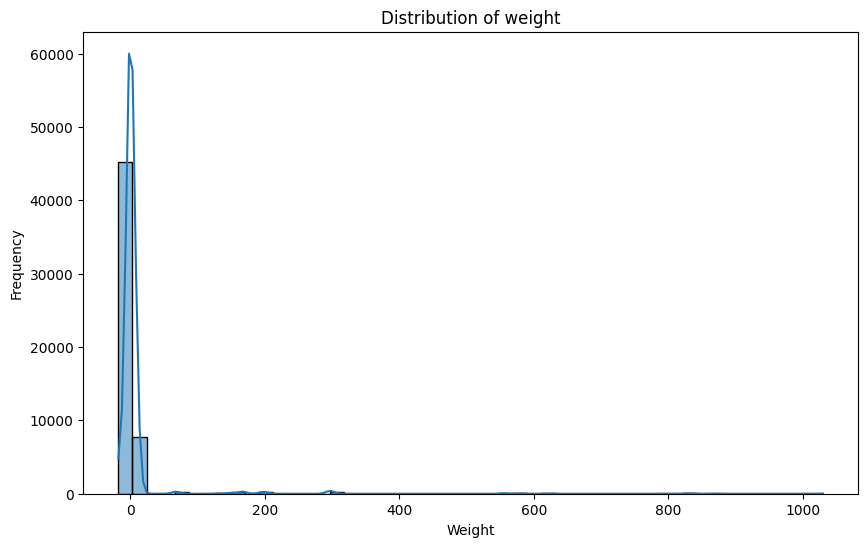

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(X_train['weight'], bins=50, kde=True)
plt.title('Distribution of weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()

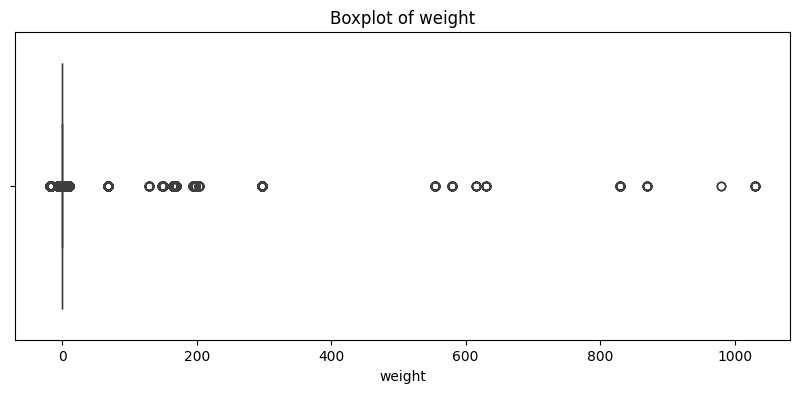

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(x=X_train['weight'])
plt.title("Boxplot of weight")
plt.show()

In [ ]:
X_train['weight'].sort_values(ascending=False).head(10)

,weight
48342,1029.87
11531,1029.87
25332,1029.87
4032,1029.87
33731,1029.87
817,1029.87
9961,1029.87
20457,1029.87
35833,1029.87
12428,1029.87


In [ ]:
feature_4_insights = "The weight attribute shows an extremely skewed distribution towards the right, with the majority of instances having lower values and only a few instances having exceptionally high weights. The large gap between the median value (0.00) and the highest value (1029.87) points to the presence of many outliers in the dataset and considerable variance. This is further evidenced by the histogram and boxplot, which show the presence of several heavy-weight outliers. These instances indicate exceptionally heavy products compared to other typical retail products. These may be specialized products, bulk commodities, or products with complicated operations involved in shipment. It should also be noted that there were negative instances, which can be attributed to the normalization process done during data preprocessing. As far as businesses are concerned, very heavy products can have an effect on transportation fees, storage needs, deal value, and purchase behavior. For this reason, deals concerning very heavy products could be an indicator of some irregular business operations. An example of a problem associated with this variable is that very heavy products that are normal can show up as statistical outliers without being considered as irregular operations. Hence, extra information on the type of product and pricing behavior would be needed in order to recognize irregular business dealings."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

---
## D. Feature Selection


In [ ]:
features_list = list(X_train.columns)
print(features_list)

['order_quantity', 'unit_price_discount', 'sub_total', 'is_manufactured', 'days_to_manufacture', 'weight', 'safety_stock_level', 'online_order_flag', 'discounted_amount', 'price_difference_ratio', 'order_month', 'product_line_M', 'product_line_R', 'product_line_S', 'product_line_T', 'product_line_Unknown', 'class_H', 'class_L', 'class_M', 'class_Unknown', 'color_Black', 'color_Blue', 'color_Multi', 'color_Red', 'color_Silver', 'color_Silver/Black', 'color_Unknown', 'color_White', 'color_Yellow', 'subcategory_name_Bib-Shorts', 'subcategory_name_Bike Racks', 'subcategory_name_Bike Stands', 'subcategory_name_Bottles and Cages', 'subcategory_name_Bottom Brackets', 'subcategory_name_Brakes', 'subcategory_name_Caps', 'subcategory_name_Chains', 'subcategory_name_Cleaners', 'subcategory_name_Cranksets', 'subcategory_name_Derailleurs', 'subcategory_name_Fenders', 'subcategory_name_Forks', 'subcategory_name_Gloves', 'subcategory_name_Handlebars', 'subcategory_name_Headsets', 'subcategory_name_He

In [ ]:
feature_selection_explanations = "The last set of features comprises transactional, financial, operational, time-based, and categorical features that have been found to be important for modelling anomalies. The chosen features consist of pricing, discount, operation-related features for products, inventory-related features, ratio-based financial features, time-based features, and one-hot encoded categorical features. It is especially important to identify those features which could effectively model anomalous transactional activity, pricing, operations, and purchases. The reason why features like price_difference_ratio and discounted_amount have been added here is their additional financial perspective on top of transactional features. The categorical features were encoded via the method of one-hot encoding to retain the information regarding each category while making sure that the dataset is compatible with machine learning models. The numerical features were normalized via the method of RobustScaler to minimize the influence of outliers in the data while retaining the information regarding any unusual behavior patterns present in the data."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation <put_name_here>

In [ ]:
data_cleaning_1_explanations = "There were no further transformations made in this step since the datasets collected from the preparation notebook were already subjected to a lot of pre-processing techniques that were tailored to the requirements of building models for anomaly detection. All numerical transformations, one-hot encodings of categorical variables, creation of transactional variables, and scaling of financial features that can be used by Isolation Forest algorithms were already done prior to feeding the dataset into this notebook. Performing further transformations might lead to unnecessary redundancies and complexities and might even result in distortion of patterns already created through pre-processing."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

---
## F. Feature Engineering

In [ ]:
feature_engineering_n_explanations = "At this point, no other additional features were generated because the imported data already had multiple engineered features that were built for anomaly detection modeling purposes. These features included price_difference_ratio, discounted_amount, order_month, and weight_category, which were generated before to account for anomalies in pricing, discounts, ordering month, and the product operations. Any further generation of new engineered features may lead to unnecessary complexity within the datasets and lack of model interpretability without much additional benefit. Thus, the current set of engineered features was deemed enough for our anomaly detection models."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets

In [ ]:
print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Testing shape:", X_test.shape)

Training shape: (54113, 75)
Validation shape: (11596, 75)
Testing shape: (11596, 75)


In [ ]:
data_splitting_explanations = "The training, validation, and testing datasets were imported directly from the preparation notebook, where data cleaning, feature engineering, encoding, scaling, and dataset splitting were previously completed. Reusing the prepared datasets ensures consistency across the anomaly detection pipeline and prevents unnecessary duplication of preprocessing steps."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation

In [ ]:
data_transformation_1_explanations = "No additional data transformations were required at this stage because the datasets imported from the preparation notebook had already undergone cleaning, feature engineering, encoding, scaling, and preprocessing procedures suitable for anomaly detection modelling. The datasets were considered fully prepared for Isolation Forest training, with consistent feature structures, no missing values, and appropriately transformed numerical and categorical variables."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## H. Save Datasets

> Do not change this code

In [ ]:
# Placeholder target variables for unsupervised anomaly detection

y_train = pd.Series(dtype='float64')
y_val = pd.Series(dtype='float64')
y_test = pd.Series(dtype='float64')

In [ ]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
algorithm_selection_explanations = "The reason for choosing Isolation Forest is because the method was developed with an objective of conducting anomaly detection in an unsupervised manner and is highly efficient in cases of transactional datasets with a high dimension, which contain outliers, skewness, and varied behavioral trends. The process starts with the random isolation of data points in the dataset. If an observation is isolated much faster than others, then it must be treated as an anomaly because it deviates greatly from other observations. Another reason why Isolation Forest is suitable to implement is that it is computationally efficient and robust in dealing with large data sets containing multiple numeric and categorical features encoded using dummy variables. In contrast to most other distance-based anomaly detection techniques, the algorithm performs comparatively well even in presence of high-dimensional data and problems related to feature scaling, thus making it appropriate for the modified version of our transactional data set. An additional benefit of Isolation Forest is that it does not need labelled data samples for anomalies during the training phase, a key requirement associated with an unsupervised anomaly detection problem considered in our project. An obvious drawback associated with Isolation Forest is that it can misclassify rare business transactions as anomalies."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [ ]:
contamination = 0.02
n_estimators = 100
random_state = 42

isolation_forest = IsolationForest(
    contamination=contamination,
    n_estimators=n_estimators,
    random_state=random_state
)

print(isolation_forest)

IsolationForest(contamination=0.02, random_state=42)


In [ ]:
hyperparameters_selection_explanations = "The selected parameters were chosen after considering the sensitivity to detect anomalies, stability of the model, efficiency of computations, and the business understanding aspect. The contamination parameter was set to 0.02, based on the assumption that about 2% of the transactions would have an abnormal or suspicious behavior. This number seemed reasonable because in the retail business domain, abnormal transactions would form a minority part of the overall transaction data. The number of isolation trees (n_estimators) is defined as 100 so that the model is sufficiently stable and allows for effective isolation of anomalies within the transaction data set. The use of several isolation trees ensures lower variance and more consistent anomaly detection behavior. The random_state parameter is assigned the value 42 to allow for repeatable result generation during experiment repetitions. The chosen hyperparameters are expected to ensure both adequate sensitivity to detect rare anomalies and reduced likelihood of mislabeling normal retail transactions as anomalies."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [ ]:
isolation_forest.fit(X_train)

IsolationForest(contamination=0.02, random_state=42)

### J.4 Model Technical Performance

> Provide some explanations on model performance


In [ ]:
train_predictions = isolation_forest.predict(X_train)
val_predictions = isolation_forest.predict(X_val)
test_predictions = isolation_forest.predict(X_test)

# Convert predictions
# Normal = 0
# Anomaly = 1

train_anomalies = np.where(train_predictions == -1, 1, 0)
val_anomalies = np.where(val_predictions == -1, 1, 0)
test_anomalies = np.where(test_predictions == -1, 1, 0)

# Display anomaly counts

print("Training anomalies:")
print(pd.Series(train_anomalies).value_counts())

print("\nValidation anomalies:")
print(pd.Series(val_anomalies).value_counts())

print("\nTesting anomalies:")
print(pd.Series(test_anomalies).value_counts())

# Display anomaly percentages

print("\nTraining anomaly percentage:",
      round(train_anomalies.mean() * 100, 2), "%")

print("Validation anomaly percentage:",
      round(val_anomalies.mean() * 100, 2), "%")

print("Testing anomaly percentage:",
      round(test_anomalies.mean() * 100, 2), "%")

Training anomalies:
0    53032
1     1081
Name: count, dtype: int64

Validation anomalies:
0    11350
1      246
Name: count, dtype: int64

Testing anomalies:
0    11389
1      207
Name: count, dtype: int64

Training anomaly percentage: 2.0 %
Validation anomaly percentage: 2.12 %
Testing anomaly percentage: 1.79 %


In [ ]:
model_performance_explanations = "The Isolation Forest model has revealed a rather insignificant number of outliers in each of the train, validation, and test datasets, with the number of anomalies being approximately equal to the pre-defined contamination rate of 2%. More specifically, the model classified 2.0%, 2.12%, and 1.79% of the observations as outliers in the training, validation, and test datasets, respectively. It can be assumed that the similarity in the number of outliers in each dataset proves the stability of the model and its acceptable generalisation ability when processing novel data. On the other hand, from a business point of view, a rather insignificant number of outliers is justified because in reality, only a small percentage of transactions can be considered anomalous in retail trade. Moreover, the findings imply that the chosen contamination level provided adequate sensitivity for anomaly detection without producing too many anomalies. It is critical to keep a moderate level of anomalies since a high level of sensitivity for anomalies can result in too many false alarms, thus making it impractical. A drawback of the current experiment is that there are no labels for anomalies in the dataset, meaning that common performance metrics, such as accuracy, precision, and recall, cannot be used to evaluate model performance."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [ ]:
business_impact_summary = pd.DataFrame({
    'Dataset': ['Training', 'Validation', 'Testing'],
    'Anomaly_Percentage': [2.0, 2.12, 1.79]
})

business_impact_summary

,Dataset,Anomaly_Percentage
0,Training,2.00
1,Validation,2.12
2,Testing,1.79


In [ ]:
business_impacts_explanations = "From the Isolation Forest model, the percentage of outliers was found to be relatively low and consistent for each of the datasets used, with an anomaly percentage of 2.00% in the training dataset, 2.12% in the validation dataset, and 1.79% in the testing dataset. Consistency in the anomaly percentages found indicates the generalisation capacity of the algorithm in detecting anomalies in unseen transactional data while maintaining consistency in its operation regardless of the dataset split. In terms of business operations, the Isolation Forest algorithm can assist in improving operational monitoring of unusual price behavior, discount rates, purchasing behavior, and possibly inconsistent sales transactions requiring further investigation. The consistent and relatively low anomaly percentage rate corresponds with real-life business operations in the retail industry, where the percentage of outlier transactions is expected to be relatively low when compared to the volume of overall transactions. Anomaly detection with accuracy could help mitigate the risk of financial loss, enhance fraud monitoring procedures, facilitate better control of pricing, and assist in decision making. Nonetheless, any misprediction might lead to certain consequences. For instance, the prediction of positive anomalies could lead to the identification of some customer transactions as suspicious, thus increasing labor costs for manual processing of such transactions. On the contrary, prediction of negative anomalies might enable some abnormal transactions not to be detected at all. In general, the current findings indicate that Isolation Forest is a reliable model for anomaly detection."

In [ ]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes

In [ ]:
experiment_outcome = "Hypothesis Partially Confirmed"

In [ ]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [ ]:
experiment_results_explanations = "The experiment proved to be successful at partially proving the initial business hypothesis that the models for anomaly detection can successfully detect any abnormal transactional behavior from the sales retail dataset. Indeed, the Isolation Forest algorithm demonstrated consistent identification of anomalies at a relatively low rate of around 2% throughout all stages of analysis; training, validation, and test. Thus, it can be stated that the model successfully generalizes to unseen transactional data and is able to isolate observations which do not conform with the overall retail behavior in terms of the dataset. Nevertheless, the hypothesis was partially proved since no anomalies or frauds were marked in the dataset. Thus, it will be impossible to verify the quality of anomalies detected by the algorithm through the application of such metrics as accuracy, precision, or recall. Nevertheless, it can be concluded that some sort of business validation of these anomalies is required. A number of valuable observations have been made based on the experiment. Engineered features such as price_difference_ratio and discounted_amount proved highly useful for anomaly detection in identifying strong skewness, rare events, and extreme transaction behavior. Contextual analysis and understanding of the business was also proven crucial, as certain detected anomalies could actually relate to legitimate premium purchases, promotions, or simply complicated transactions, which do not require any fraud investigations. It is clear that the current method is far from being a cul-de-sac. Rather, considering the consistent anomaly detection behavior demonstrated by multiple splits of the dataset, Isolation Forest shows a lot of promise as a basis for retail transaction monitoring. Several potential next steps have been proposed and ranked based on their business impact and improvements to the models. First and foremost among the next steps would be validating the business impact of anomalies discovered with the help of operational analysis conducted by fraud analysts, pricing analysts, or retail operation experts. Such a step would generate the most significant business value since it will establish whether any of the anomalies discovered relate to real issues from the operational side. Next, it would be worthwhile to further tune the hyperparameters for the Isolation Forest algorithm, experimenting with different contamination rates and tree structures. It may potentially increase anomaly sensitivity and decrease the number of false positives. Thirdly, it would be helpful to introduce more customer-level behavioural aggregations, as well as purchase behaviour over time into the analysis to provide better context around anomalies. Finally, another algorithm, like LOF or clustering-based one, can be explored. Due to the fact that the system performance is stable enough, the presented approach can be considered to be suitable for deployment in a business environment for transactions monitoring purposes. An appropriate implementation scenario would include the implementation of an automatic scoring procedure, where the Isolation Forest algorithm would be used for detecting transactions to be manually checked by operations specialists. Prior to deployment in a business setting, further validations should be conducted in order to ensure minimal error rates."

In [ ]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)